# 📧 Email Spam Detection Using Machine Learning

### Oasis Infobyte — Data Science Internship

**Project:** Email Spam Detection  
**Track:** Data Science  
**Task:** Email Spam Detection  
**Author:** Mohamed Zufar

---

## Project Objective

The objective of this project is to build a machine learning
system that can classify text messages as either:

- HAM — legitimate message
- SPAM — unwanted/spam message

The project will use Natural Language Processing (NLP)
techniques and machine learning classification algorithms.

### Main Workflow

Dataset
→ Data Understanding
→ Exploratory Data Analysis
→ Text Preprocessing
→ Train-Test Split
→ TF-IDF Feature Extraction
→ Model Training
→ Model Evaluation
→ Model Comparison
→ Error Analysis
→ Final Prediction

#  Project Objectives

The main objectives of this project are:

- Understand and explore the spam/ham dataset.
- Clean and preprocess the text data.
- Convert text into numerical features using TF-IDF.
- Train a Multinomial Naive Bayes classifier.
- Train a second classification model.
- Evaluate both models.
- Compare Accuracy, Precision, Recall and F1 Score.
- Analyze the confusion matrix.
- Perform error analysis.
- Build a function for predicting new messages.
- Save the trained model for future inference.

#  What Are We Building?

We are building a binary text classification system.

Example:

Input:
"Congratulations! You have won a free prize!"

Expected Output:
SPAM

Input:
"Hey, are you coming to college tomorrow?"

Expected Output:
HAM

### Machine Learning Pipeline

Raw Message
↓
Text Cleaning
↓
Train/Test Split
↓
TF-IDF
↓
Machine Learning Model
↓
Prediction
↓
Evaluation

# Technologies Used

### Programming Language
- Python
### Data Processing
- Pandas
- NumPy
### Visualization
- Matplotlib
- Seaborn
### Machine Learning
- Scikit-learn
### NLP
- Text preprocessing
- TF-IDF
### Models
- Multinomial Naive Bayes
- Logistic Regression
### Model Persistence
- Joblib

In [11]:
import pandas as pd
import numpy as np

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
print("All libraries imported successfully!")

All libraries imported successfully!


#  Dataset Collection

For this project, we use the SMS Spam Collection dataset
available through Kaggle.

The dataset contains text messages labelled as either
HAM or SPAM.

The dataset will be downloaded using KaggleHub, and the
downloaded files will be inspected before loading them
into Pandas.

### Objective

Before performing any analysis, we first identify:

- The downloaded dataset location
- Available files
- File format
- Dataset structure
- Required columns

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


#  Inspect Downloaded Dataset Files

The dataset has been downloaded successfully using KaggleHub.

Before loading the data, we will inspect the extracted
directory to identify the available dataset files.

This ensures that we work with the actual downloaded file
rather than assuming its filename or structure.

In [13]:
import os

print("Dataset directory:")
print(path)

print("\nFiles available in the dataset:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Dataset directory:
/kaggle/input/sms-spam-collection-dataset

Files available in the dataset:
/kaggle/input/sms-spam-collection-dataset/spam.csv


#  Load the Raw Dataset

The downloaded dataset contains a CSV file named `spam.csv`.

We will load this file into a Pandas DataFrame and inspect
its original structure before performing any cleaning or
transformation.

At this stage, the goal is only to understand the raw data.

In [14]:
import pandas as pd
import os

dataset_file = os.path.join(path, "spam.csv")

df = pd.read_csv(
    dataset_file,
    encoding="latin-1"
)

print("Dataset loaded successfully!")


Dataset loaded successfully!


#  Initial Dataset Inspection

Before preprocessing the data, we will inspect:

- Number of rows and columns
- Column names
- First few records
- Data types
- Missing values
- Duplicate records

This helps us understand the original dataset structure
before making any modifications.

In [15]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (5572, 5)

Column Names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

First 5 Rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Data Types

We will inspect the data types of every column.

This helps us identify which columns contain the message
text and which column contains the target label.

In [16]:
df.dtypes

,0
v1,object
v2,object
Unnamed: 2,object
Unnamed: 3,object
Unnamed: 4,object


#  Dataset Information

The `info()` method provides an overview of:

- Number of records
- Column names
- Non-null values
- Data types
- Memory usage

This is useful for identifying potential data-quality issues.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


#  Missing Value Analysis

Missing values can affect machine learning models.

We will check the number of missing values in each column
before deciding how they should be handled.

In [18]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


# Duplicate Record Analysis

Duplicate messages can cause repeated observations in the
dataset.

We will first count duplicate rows. We will remove them later
during the data-cleaning stage after completing the raw-data
inspection.

In [19]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 403


In [20]:
df.columns.tolist()

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

In [21]:
print(df.shape)

(5572, 5)


In [22]:
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [23]:
display(df.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [24]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


# Raw Dataset Structure Analysis

The raw dataset contains 5,572 records and 5 columns.

The columns `v1` and `v2` contain the primary information
required for this project:

- `v1` — message category
- `v2` — message text

The remaining columns are named `Unnamed: 2`, `Unnamed: 3`,
and `Unnamed: 4`.

Before removing these columns, we will investigate their
non-null values to determine whether they contain useful
information.

In [25]:
# Check how many non-null values exist in every column

non_null_counts = df.notnull().sum()

print("Non-null values in each column:")
display(non_null_counts)

Non-null values in each column:


,0
v1,5572
v2,5572
Unnamed: 2,50
Unnamed: 3,12
Unnamed: 4,6


#  Analysis of Additional Columns

The dataset contains three additional columns:

- Unnamed: 2
- Unnamed: 3
- Unnamed: 4

We will check whether these columns contain meaningful
data or are mostly empty.

In [26]:
extra_columns = [
    "Unnamed: 2",
    "Unnamed: 3",
    "Unnamed: 4"
]

for column in extra_columns:
    print(f"\n{column}")
    print("Non-null values:", df[column].notna().sum())
    print("Unique non-null values:")
    display(df[column].dropna().head(10))


Unnamed: 2
Non-null values: 50
Unique non-null values:


,Unnamed: 2
95,PO Box 5249
281,the person is definitely special for u..... B...
444,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...
671,"wanted to say hi. HI!!!\"" Stop? Send STOP to ..."
710,"this wont even start........ Datz confidence.."""
899,PO Box 5249
1038,GN
1127,".;-):-D"""
1266,just been in bedbut mite go 2 thepub l8tr if u...
1384,"bt not his girlfrnd... G o o d n i g h t . . .@"""



Unnamed: 3
Non-null values: 12
Unique non-null values:


,Unnamed: 3
95,"MK17 92H. 450Ppw 16"""
281,why to miss them
899,"MK17 92H. 450Ppw 16"""
1038,GE
2170,"U NO THECD ISV.IMPORTANT TOME 4 2MORO\"""""
2255,i wil tolerat.bcs ur my someone..... But
3145,"ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\"""""
3506,"whoever is the KING\""!... Gud nyt"""
3525,TX 4 FONIN HON
4668,"\""OH No! COMPETITION\"". Who knew"



Unnamed: 4
Non-null values: 6
Unique non-null values:


,Unnamed: 4
281,"just Keep-in-touch\"" gdeve.."""
1038,"GNT:-)"""
2255,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,"one day these two will become FREINDS FOREVER!"""
5048,"GNT:-)"""


# Analysis of Additional Columns

The raw CSV contains three additional columns:

- `Unnamed: 2`
- `Unnamed: 3`
- `Unnamed: 4`

These columns contain a small number of non-null text
fragments, while the majority of their values are missing.

The values appear to be overflowed fragments from some
records rather than independent features required for the
spam classification task.

We therefore retain the original raw DataFrame for reference
but will use only the `v1` and `v2` fields for the core
classification dataset.

In [27]:
extra_columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

extra_analysis = pd.DataFrame({
    "Non-Null Count": df[extra_columns].notna().sum(),
    "Missing Count": df[extra_columns].isna().sum(),
    "Missing Percentage": (
        df[extra_columns].isna().mean() * 100
    ).round(2)
})

display(extra_analysis)

,Non-Null Count,Missing Count,Missing Percentage
Unnamed: 2,50,5522,99.10
Unnamed: 3,12,5560,99.78
Unnamed: 4,6,5566,99.89


#  Create the Core Dataset

For the spam classification problem, we require two fields:

- `v1` → message label
- `v2` → message text

We will rename these fields to more descriptive names:

- `label`
- `message`

The original raw DataFrame is preserved separately.

In [28]:
data = df[["v1", "v2"]].copy()

data.columns = ["label", "message"]

display(data.head())

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#  Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure,
distribution, and characteristics of the dataset before
building a machine learning model.

In this section, we will analyze:

- Class distribution
- Class percentages
- Message length
- Word count
- Character count
- HAM vs SPAM message characteristics
- Sample messages from each class

The purpose is to understand the data and identify useful
patterns before applying Natural Language Processing
techniques.

##  Class Distribution

We first determine how many messages belong to each class.

The dataset contains two classes:

- HAM
- SPAM

Understanding the class distribution is important because
an imbalance between classes can affect how we interpret
model performance.

In [29]:
class_counts = data_clean["label"].value_counts()

print("Number of messages in each class:")
display(class_counts)

NameError: name 'data_clean' is not defined

In [30]:
data = df[["v1", "v2"]].copy()

data.columns = ["label", "message"]

print("Core dataset shape:", data.shape)

display(data.head())

Core dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
data_clean = data.copy()

# Remove missing label/message records
data_clean = data_clean.dropna(
    subset=["label", "message"]
)

# Remove duplicate records
data_clean = data_clean.drop_duplicates()

# Reset index
data_clean = data_clean.reset_index(drop=True)

print("Original rows:", len(data))
print("Cleaned rows:", len(data_clean))
print("Rows removed:", len(data) - len(data_clean))

Original rows: 5572
Cleaned rows: 5169
Rows removed: 403


In [32]:
print("Clean dataset shape:", data_clean.shape)

print("\nMissing values:")
display(data_clean.isnull().sum())

print("\nDuplicate rows:")
print(data_clean.duplicated().sum())

print("\nClass distribution:")
display(data_clean["label"].value_counts())

Clean dataset shape: (5169, 2)

Missing values:


,0
label,0
message,0



Duplicate rows:
0

Class distribution:


,count
label,
ham,4516
spam,653


In [33]:
class_counts = data_clean["label"].value_counts()

print("Number of messages in each class:")
display(class_counts)

Number of messages in each class:


,count
label,
ham,4516
spam,653


##  Class Distribution

After removing duplicate records, the cleaned dataset contains
5,169 messages.

The dataset contains two classes:

- HAM — 4,516 messages
- SPAM — 653 messages

HAM represents approximately 87.37% of the dataset, while
SPAM represents approximately 12.63%.

Therefore, the dataset is imbalanced, with HAM messages being
the majority class.

This class imbalance should be considered when evaluating
the machine learning models. Accuracy alone may not provide
a complete picture of model performance.

In [34]:
class_counts = data_clean["label"].value_counts()

display(class_counts)

,count
label,
ham,4516
spam,653


##  Class Percentage

We calculate the percentage of each class to understand the
proportion of HAM and SPAM messages in the cleaned dataset.

In [35]:
class_percentages = (
    data_clean["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_percentages)

,proportion
label,
ham,87.37
spam,12.63


In [36]:
class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(class_distribution)

,Count,Percentage
label,,
ham,4516,87.37
spam,653,12.63


##  HAM vs SPAM Distribution

The following bar chart visualizes the distribution of HAM
and SPAM messages.

The visualization makes the class imbalance easier to observe.

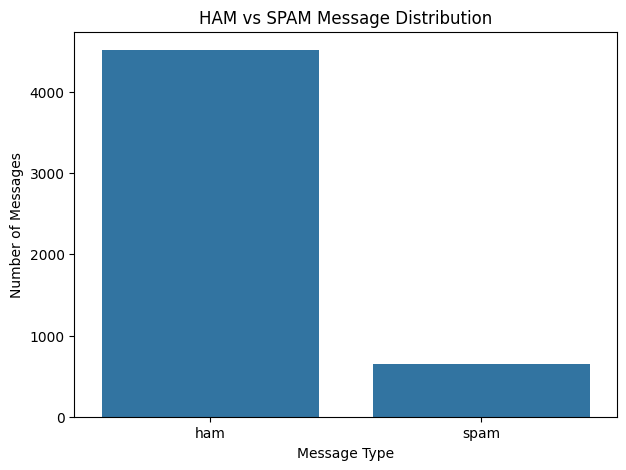

In [37]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data_clean,
    x="label"
)

plt.title("HAM vs SPAM Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

##  Message Length Analysis

Message length is one of the basic characteristics we can
extract from the raw text.

We calculate the number of characters in every message and
use this information for exploratory analysis.

This feature is used here for EDA and is not automatically
treated as a model feature.

In [41]:
data_clean["message_length"] = (
    data_clean["message"].str.len()
)

display(
    data_clean[
        ["label", "message", "message_length"]
    ].head()
)

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [40]:
data_clean["message_length"].describe()

,message_length
count,5169.000000
mean,78.977945
std,58.236293
min,2.000000
25%,36.000000
50%,60.000000
75%,117.000000
max,910.000000


##  Message Length by Class

We compare the character length of HAM and SPAM messages.

This allows us to determine whether message length differs
between the two classes in this dataset.

In [ ]:
length_stats = (
    data_clean
    .groupby("label")["message_length"]
    .describe()
)

display(length_stats)

### EDA Finding — Message Length

The message-length analysis shows a noticeable difference
between the two classes.

HAM messages have an average length of approximately
70.46 characters, while SPAM messages have an average
length of approximately 137.89 characters.

Therefore, SPAM messages are approximately 1.96 times
longer on average in this dataset.

However, message length alone cannot be used to reliably
classify a message as SPAM or HAM. The HAM class also
contains some very long messages, with a maximum observed
length of 910 characters.

Therefore, we need to analyze the actual textual content
rather than relying only on message length.

In [ ]:
data_clean["word_count"] = data_clean["message"].str.split().str.len()

In [ ]:
data_clean[["message", "word_count"]].head()

In [ ]:
word_count_stats = data_clean.groupby("label")["word_count"].describe()

word_count_stats

## EDA Finding — Word Count

The average number of words differs between the two classes:

- **HAM:** 14.13 words on average
- **SPAM:** 23.68 words on average

The median word count is also higher for SPAM:

- **HAM:** 11 words
- **SPAM:** 25 words

HAM messages show greater variation, with a maximum of 171 words compared with 35 words for SPAM.

This indicates that message length and word count may provide useful signals, but they are not sufficient for reliable spam classification. The model must learn meaningful patterns from the actual text.

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data_clean,
    x="label",
    y="word_count"
)

plt.title("Word Count Distribution by Message Class")
plt.xlabel("Message Class")
plt.ylabel("Number of Words")
plt.show()

ValueError: Could not interpret value `word_count` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

## Sample HAM and SPAM Messages

Before building the NLP pipeline, we will inspect representative examples from both classes.

This helps us understand the types of language, offers, keywords, and patterns that may distinguish spam from legitimate messages.

In [44]:
# Display sample HAM messages

print("===== SAMPLE HAM MESSAGES =====\n")

ham_samples = data_clean[data_clean["label"] == "ham"]["message"].sample(
    5,
    random_state=42
)

for i, message in enumerate(ham_samples, 1):
    print(f"HAM {i}: {message}\n")

===== SAMPLE HAM MESSAGES =====

HAM 1: Come to me, slave. Your doing it again ... Going into your shell and unconsciously avoiding me ... You are making me unhappy :-(

HAM 2: U meet other fren dun wan meet me ah... Muz b a guy rite...

HAM 3: G says you never answer your texts, confirm/deny

HAM 4: K so am I, how much for an 8th? Fifty?

HAM 5: HMM yeah if your not too grooved out! And im looking forward to my pound special :)



In [45]:
# Display sample SPAM messages

print("===== SAMPLE SPAM MESSAGES =====\n")

spam_samples = data_clean[data_clean["label"] == "spam"]["message"].sample(
    5,
    random_state=42
)

for i, message in enumerate(spam_samples, 1):
    print(f"SPAM {i}: {message}\n")

===== SAMPLE SPAM MESSAGES =====

SPAM 1: Romantic Paris. 2 nights, 2 flights from å£79 Book now 4 next year. Call 08704439680Ts&Cs apply.

SPAM 2: URGENT! Your mobile No *********** WON a å£2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362220 ASAP! BOX97N7QP, 150ppm

SPAM 3: Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or å£250 cash every wk. Txt POD to 84128 Ts&Cs www.textpod.net custcare 08712405020.

SPAM 4: Wan2 win a Meet+Greet with Westlife 4 U or a m8? They are currently on what tour? 1)Unbreakable, 2)Untamed, 3)Unkempt. Text 1,2 or 3 to 83049. Cost 50p +std text

SPAM 5: You can stop further club tones by replying \STOP MIX\" See my-tone.com/enjoy. html for terms. Club tones cost GBP4.50/week. MFL



## EDA Finding — Message Content

Inspection of representative messages shows noticeable textual differences between HAM and SPAM messages.

### SPAM patterns observed

- Promotional offers and prizes
- Urgency and calls to action
- Monetary amounts
- Phone numbers
- URLs
- Terms and conditions

### HAM patterns observed

- Personal conversations
- Questions and replies
- Informal language and abbreviations
- Everyday communication

These observations suggest that the actual text contains useful information for classification.

However, these patterns are not deterministic rules. Some legitimate messages may contain numbers, links, or urgent language, while spam messages may not always contain the same patterns.

Therefore, the project will use NLP techniques to learn statistical patterns from the training data.

## Label Encoding

The dataset currently represents the target class using text labels:

- `ham` → legitimate message
- `spam` → unwanted/promotional message

Machine-learning algorithms require numerical target values, so we encode the labels as:

- `ham` → `0`
- `spam` → `1`

Using `1` for SPAM will also make the later precision, recall, and confusion-matrix interpretation intuitive.

In [46]:
data_clean["label_encoded"] = data_clean["label"].map({
    "ham": 0,
    "spam": 1
})


In [47]:
data_clean[["label", "label_encoded"]].head(10)

,label,label_encoded
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0
5,spam,1
6,ham,0
7,ham,0
8,spam,1
9,spam,1


In [48]:
data_clean["label_encoded"].value_counts()

,count
label_encoded,
0,4516
1,653


## Features and Target

For our spam classification problem:

- **Feature (X):** the text message that the model will analyze.
- **Target (y):** whether the message is HAM (`0`) or SPAM (`1`).

We keep the original text because the next stage will convert the messages into numerical TF-IDF features.

In [49]:
X = data_clean["message"]
y = data_clean["label_encoded"]

In [50]:
print("Number of messages:", len(X))
print("Number of labels:", len(y))

Number of messages: 5169
Number of labels: 5169


## Train-Test Split

The dataset is divided into two parts:

### Training Set
Used to learn patterns from the messages.

### Test Set
Used only after training to evaluate how well the model performs on unseen messages.

We use an 80/20 split.

The `stratify` parameter preserves the original HAM/SPAM class distribution in both datasets. This is especially important because the dataset is imbalanced.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 4135
Testing samples: 1034

Training class distribution:
label_encoded
0    3613
1     522
Name: count, dtype: int64

Testing class distribution:
label_encoded
0    903
1    131
Name: count, dtype: int64


## Text Preprocessing

Raw SMS messages contain differences in capitalization, punctuation, and whitespace.

We will normalize the text before converting it into numerical features.

The preprocessing steps are:

1. Convert text to lowercase
2. Remove punctuation
3. Normalize extra whitespace

We will preserve numbers and other potentially useful information because they may contain signals relevant to spam detection.

In [53]:
import re
import string

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [54]:
sample_message = X_train.iloc[0]

print("Original message:")
print(sample_message)

print("\nCleaned message:")
print(clean_text(sample_message))

Original message:
Cool. So how come you havent been wined and dined before?

Cleaned message:
cool so how come you havent been wined and dined before


In [55]:
print("Original:")
print(X_train.iloc[0])

print("\nAfter preprocessing:")
print(X_train_clean.iloc[0])

Original:
Cool. So how come you havent been wined and dined before?

After preprocessing:


NameError: name 'X_train_clean' is not defined

In [56]:
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [57]:
print("Original:")
print(X_train.iloc[0])

print("\nAfter preprocessing:")
print(X_train_clean.iloc[0])

Original:
Cool. So how come you havent been wined and dined before?

After preprocessing:
cool so how come you havent been wined and dined before


## TF-IDF Vectorization

Machine-learning models cannot directly understand raw text.

TF-IDF (Term Frequency–Inverse Document Frequency) converts each message into a numerical vector.

It gives higher importance to words that are useful for distinguishing messages while reducing the importance of words that occur frequently across many messages.

We will use:

- Unigrams: individual words
- Bigrams: two-word combinations
- Maximum 5,000 features

The vectorizer will be fitted only on the training data to prevent data leakage.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [59]:
X_train_tfidf = tfidf.fit_transform(X_train_clean)

In [60]:
X_test_tfidf = tfidf.transform(X_test_clean)

In [61]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


## Multinomial Naive Bayes

Multinomial Naive Bayes is a common baseline algorithm for text classification.

It learns the relationship between words/features and the target classes:

- `0` → HAM
- `1` → SPAM

We will train it using the TF-IDF representation of the training messages.

The trained model will then predict the classes of previously unseen test messages.

In [62]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

## Naive Bayes Predictions

After training, we use the model to predict whether each message in the test set is HAM or SPAM.

The test data was not used during model training, so these predictions provide an estimate of how the model performs on unseen messages.

In [63]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [64]:
print("Actual labels:")
print(y_test.iloc[:10].values)

print("\nPredicted labels:")
print(y_pred_nb[:10])

Actual labels:
[0 0 0 0 0 0 0 0 0 0]

Predicted labels:
[0 0 0 0 0 0 0 0 0 0]


In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("-" * 30)
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

Naive Bayes Results
------------------------------
Accuracy : 0.9652
Precision: 1.0000
Recall   : 0.7252
F1-Score : 0.8407


In [66]:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["HAM", "SPAM"]
))

              precision    recall  f1-score   support

         HAM       0.96      1.00      0.98       903
        SPAM       1.00      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.97      0.96      1034



## Naive Bayes — Evaluation Findings

The Multinomial Naive Bayes model achieved:

- Accuracy: 96.52%
- SPAM Precision: 100.00%
- SPAM Recall: 72.52%
- SPAM F1-score: 84.07%

The model has perfect SPAM precision on the test set, meaning every message predicted as SPAM was actually SPAM.

However, SPAM recall is 72.52%, meaning the model detected only about 73% of the actual SPAM messages in the test set.

This indicates that the baseline model is conservative when predicting SPAM: it avoids incorrectly sending legitimate messages to the SPAM class, but consequently misses some actual SPAM messages.

Therefore, recall and the confusion matrix are important for evaluating this spam-classification system.

## Naive Bayes — Confusion Matrix

A confusion matrix breaks the predictions into four categories:

- **True Negative (TN):** HAM correctly classified as HAM
- **False Positive (FP):** HAM incorrectly classified as SPAM
- **False Negative (FN):** SPAM incorrectly classified as HAM
- **True Positive (TP):** SPAM correctly classified as SPAM

For spam detection, false negatives are particularly important because they represent actual SPAM messages that were missed.

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)

[[903   0]
 [ 36  95]]


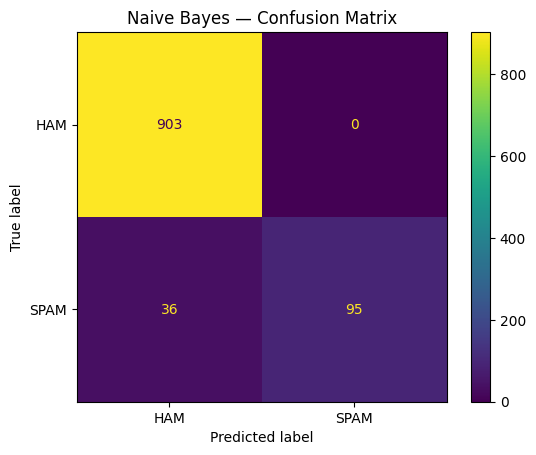

In [68]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["HAM", "SPAM"]
)

disp.plot()
plt.title("Naive Bayes — Confusion Matrix")
plt.show()

## Naive Bayes — Confusion Matrix Findings

The confusion matrix shows:

- True Negatives (TN): 903
- False Positives (FP): 0
- False Negatives (FN): 36
- True Positives (TP): 95

The model correctly classified all 903 HAM messages and did not incorrectly classify any HAM message as SPAM.

However, 36 of the 131 actual SPAM messages were classified as HAM.

Therefore, the main weakness of this baseline model is its SPAM recall rather than its SPAM precision.

## Logistic Regression

Logistic Regression is another strong baseline for text classification.

It will use the same TF-IDF features used by Naive Bayes.

Using the same training and testing data allows us to compare the two algorithms fairly.

We will evaluate Logistic Regression using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [69]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [70]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9642
Precision: 0.9896
Recall   : 0.7252
F1-Score : 0.8370


In [72]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["HAM", "SPAM"]
))

              precision    recall  f1-score   support

         HAM       0.96      1.00      0.98       903
        SPAM       0.99      0.73      0.84       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.96      0.96      1034



## Model Comparison — Naive Bayes vs Logistic Regression

Both models were trained and evaluated using the same TF-IDF features and the same train-test split.

### Naive Bayes

- Accuracy: 96.52%
- SPAM Precision: 100.00%
- SPAM Recall: 72.52%
- SPAM F1-score: 84.07%

### Logistic Regression

- Accuracy: 96.42%
- SPAM Precision: 98.96%
- SPAM Recall: 72.52%
- SPAM F1-score: 83.70%

Both models detected 95 of the 131 actual SPAM messages and missed 36.

Naive Bayes produced no false-positive SPAM predictions on this test set, while Logistic Regression produced one false-positive SPAM prediction.

For this particular experiment, Naive Bayes achieved slightly higher accuracy, precision, and F1-score.

## Logistic Regression — Confusion Matrix

The confusion matrix allows us to compare the Logistic Regression errors with the Naive Bayes model.

We are particularly interested in:

- False positives: HAM incorrectly classified as SPAM
- False negatives: SPAM incorrectly classified as HAM

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[902   1]
 [ 36  95]]


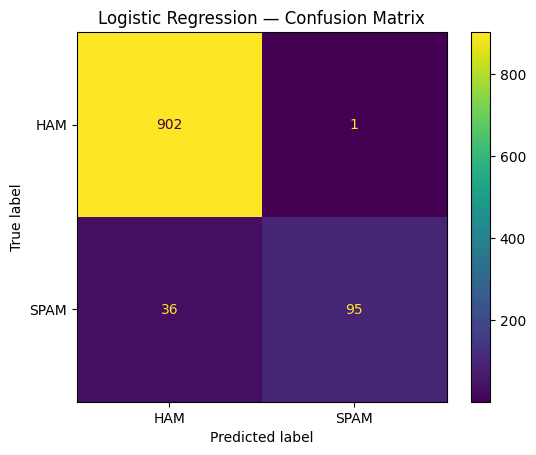

In [74]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["HAM", "SPAM"]
)

disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

## Model Performance Comparison

We compare the two baseline models using the same test dataset.

The main metrics are accuracy, precision, recall, and F1-score.

Because this is a spam-classification problem, SPAM precision and recall are especially important.

In [75]:
comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr
    ],
    "Precision": [
        precision_nb,
        precision_lr
    ],
    "Recall": [
        recall_nb,
        recall_lr
    ],
    "F1-Score": [
        f1_nb,
        f1_lr
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.965184,1.000000,0.725191,0.840708
1,Logistic Regression,0.964217,0.989583,0.725191,0.837004


## Error Analysis — False Negatives

A false negative occurs when an actual SPAM message is incorrectly classified as HAM.

For a spam detection system, false negatives are important because they represent unwanted messages that the classifier failed to identify.

We will inspect the false-negative messages to understand which types of spam are difficult for the current TF-IDF + Naive Bayes model to detect.

In [76]:
false_negative_mask = (y_test == 1) & (y_pred_nb == 0)

false_negatives = pd.DataFrame({
    "message": X_test[false_negative_mask],
    "actual": y_test[false_negative_mask],
    "predicted": y_pred_nb[false_negative_mask]
})

print("Number of false negatives:", len(false_negatives))

false_negatives

Number of false negatives: 36


,message,actual,predicted
5137,Want explicit SEX in 30 secs? Ring 02073162414...,1,0
520,You will recieve your tone within the next 24h...,1,0
2695,Send a logo 2 ur lover - 2 names joined by a h...,1,0
483,Congrats! 1 year special cinema pass for 2 is ...,1,0
2906,"Hi babe its Jordan, how r u? Im home from abro...",1,0
1610,Hi if ur lookin 4 saucy daytime fun wiv busty ...,1,0
4752,TheMob>Hit the link to get a premium Pink Pant...,1,0
1892,Guess what! Somebody you know secretly fancies...,1,0
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,0
4363,Customer service announcement. We recently tri...,1,0


## Error Analysis — False Negative Patterns

The false-negative analysis shows that the baseline TF-IDF + Naive Bayes model misses several types of SPAM.

Observed patterns include:

1. Promotional and paid-service messages
2. Premium chat and subscription-style messages
3. Messages designed to resemble normal conversations
4. Very short messages containing limited textual information
5. Informal SMS abbreviations and unusual spellings

These errors demonstrate a limitation of a basic bag-of-words representation. TF-IDF captures statistical word importance but does not understand semantic context.

The error analysis therefore provides useful directions for improving the classifier, including better feature representation, character-level features, threshold optimization, and eventually transformer-based models.

In [77]:
nb_probabilities = nb_model.predict_proba(X_test_tfidf)

# Probability of the SPAM class
spam_probabilities = nb_probabilities[:, 1]

false_negative_analysis = pd.DataFrame({
    "message": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred_nb,
    "spam_probability": spam_probabilities
})

false_negative_analysis = false_negative_analysis[
    (false_negative_analysis["actual"] == 1) &
    (false_negative_analysis["predicted"] == 0)
].sort_values(
    "spam_probability",
    ascending=False
)

print("Number of false negatives:", len(false_negative_analysis))

false_negative_analysis

Number of false negatives: 36


,message,actual,predicted,spam_probability
461,Bored housewives! Chat n date now! 0871750.77....,1,0,0.496699
239,Customer service announcement. We recently tri...,1,0,0.459221
470,Free-message: Jamster!Get the crazy frog sound...,1,0,0.446810
370,Text BANNEDUK to 89555 to see! cost 150p texto...,1,0,0.433561
105,You will recieve your tone within the next 24h...,1,0,0.425612
576,Hey I am really horny want to chat or see me n...,1,0,0.424673
539,Ever thought about living a good life with a p...,1,0,0.395721
398,Bought one ringtone and now getting texts cost...,1,0,0.381909
329,SMS. ac sun0819 posts HELLO:\You seem cool,1,0,0.366764
961,Send a logo 2 ur lover - 2 names joined by a h...,1,0,0.356328


In [78]:
false_negative_analysis[
    ["spam_probability", "message"]
].head(15)

,spam_probability,message
461,0.496699,Bored housewives! Chat n date now! 0871750.77....
239,0.459221,Customer service announcement. We recently tri...
470,0.446810,Free-message: Jamster!Get the crazy frog sound...
370,0.433561,Text BANNEDUK to 89555 to see! cost 150p texto...
105,0.425612,You will recieve your tone within the next 24h...
576,0.424673,Hey I am really horny want to chat or see me n...
539,0.395721,Ever thought about living a good life with a p...
398,0.381909,Bought one ringtone and now getting texts cost...
329,0.366764,SMS. ac sun0819 posts HELLO:\You seem cool
961,0.356328,Send a logo 2 ur lover - 2 names joined by a h...


## Classification Threshold Analysis

The classifier produces a probability of belonging to the SPAM class.

Instead of relying only on the default classification threshold, we will evaluate several thresholds.

This allows us to observe the trade-off between:

- SPAM precision
- SPAM recall
- F1-score

A lower threshold may detect more SPAM messages but can also increase false-positive HAM classifications.

In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        spam_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.50,1.000000,0.725191,0.840708
1,0.45,1.000000,0.740458,0.850877
2,0.40,0.990196,0.770992,0.866953
3,0.35,0.981481,0.809160,0.887029
4,0.30,0.973214,0.832061,0.897119
5,0.25,0.965217,0.847328,0.902439
6,0.20,0.957627,0.862595,0.907631


## Validation Set for Threshold Selection

The test set should be reserved for final evaluation.

Therefore, we will split the current training data into:

- Training set — used to train the model
- Validation set — used to select the classification threshold
- Test set — kept separate for final evaluation

This prevents us from selecting the threshold based directly on the final test results.

In [80]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training samples:", len(X_train_final))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 3308
Validation samples: 827
Test samples: 1034


In [81]:
X_train_final_clean = X_train_final.apply(clean_text)
X_val_clean = X_val.apply(clean_text)

In [82]:
tfidf_final = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_final_tfidf = tfidf_final.fit_transform(X_train_final_clean)
X_val_tfidf = tfidf_final.transform(X_val_clean)

In [83]:
nb_final = MultinomialNB()

nb_final.fit(
    X_train_final_tfidf,
    y_train_final
)

MultinomialNB()

In [84]:
val_spam_probabilities = nb_final.predict_proba(
    X_val_tfidf
)[:, 1]

In [85]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

validation_results = []

for threshold in thresholds:

    y_val_pred = (
        val_spam_probabilities >= threshold
    ).astype(int)

    validation_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1-Score": f1_score(y_val, y_val_pred)
    })

validation_df = pd.DataFrame(validation_results)

validation_df.style.format({
    "Threshold": "{:.2f}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}"
})

,Threshold,Precision,Recall,F1-Score
0,0.50,100.00%,55.77%,71.60%
1,0.45,98.41%,59.62%,74.25%
2,0.40,98.46%,61.54%,75.74%
3,0.35,98.57%,66.35%,79.31%
4,0.30,97.33%,70.19%,81.56%
5,0.25,97.50%,75.00%,84.78%
6,0.20,97.59%,77.88%,86.63%


## Threshold Selection

The classification threshold was selected using the validation set rather than the final test set.

Among the evaluated thresholds, `0.20` produced the highest F1-score:

- Precision: 97.59%
- Recall: 77.88%
- F1-score: 86.63%

The threshold is now frozen at 0.20 for the final test evaluation.

The test set will not be used to further tune this threshold.

In [86]:
FINAL_THRESHOLD = 0.20

print("Final classification threshold:", FINAL_THRESHOLD)

Final classification threshold: 0.2


In [87]:
X_test_final_clean = X_test.apply(clean_text)

X_test_final_tfidf = tfidf_final.transform(
    X_test_final_clean
)

In [88]:
test_spam_probabilities = nb_final.predict_proba(
    X_test_final_tfidf
)[:, 1]

In [89]:
y_test_threshold = (
    test_spam_probabilities >= FINAL_THRESHOLD
).astype(int)

In [90]:
final_precision = precision_score(
    y_test,
    y_test_threshold
)

final_recall = recall_score(
    y_test,
    y_test_threshold
)

final_f1 = f1_score(
    y_test,
    y_test_threshold
)

final_accuracy = accuracy_score(
    y_test,
    y_test_threshold
)

print("Final Test Results")
print("-" * 30)
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")

Final Test Results
------------------------------
Accuracy : 0.9739
Precision: 0.9643
Recall   : 0.8244
F1-Score : 0.8889


In [91]:
print(classification_report(
    y_test,
    y_test_threshold,
    target_names=["HAM", "SPAM"]
))

              precision    recall  f1-score   support

         HAM       0.98      1.00      0.99       903
        SPAM       0.96      0.82      0.89       131

    accuracy                           0.97      1034
   macro avg       0.97      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034



## Final Tuned Model — Confusion Matrix

The final model uses the classification threshold selected on the validation set.

The threshold was fixed at 0.20 before evaluating the untouched test set.

The confusion matrix shows the final numbers of:

- True Negatives
- False Positives
- False Negatives
- True Positives

In [92]:
cm_final = confusion_matrix(
    y_test,
    y_test_threshold
)

print(cm_final)

[[899   4]
 [ 23 108]]


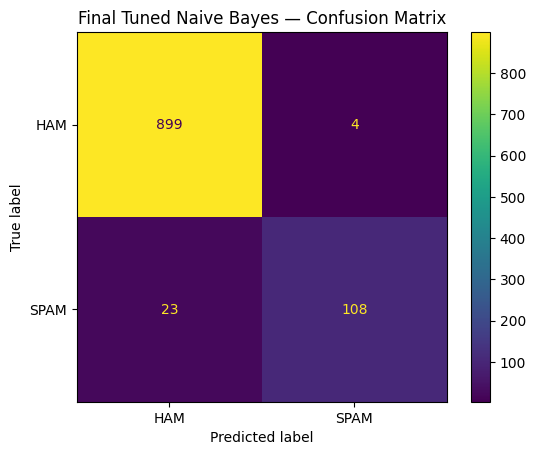

In [93]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["HAM", "SPAM"]
)

disp.plot()

plt.title("Final Tuned Naive Bayes — Confusion Matrix")
plt.show()

In [94]:
comparison_final = pd.DataFrame({
    "Version": [
        "Naive Bayes — Threshold 0.50",
        "Naive Bayes — Threshold 0.20"
    ],
    "Accuracy": [
        accuracy_nb,
        final_accuracy
    ],
    "Precision": [
        precision_nb,
        final_precision
    ],
    "Recall": [
        recall_nb,
        final_recall
    ],
    "F1-Score": [
        f1_nb,
        final_f1
    ]
})

comparison_final.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}"
})

,Version,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes — Threshold 0.50,96.52%,100.00%,72.52%,84.07%
1,Naive Bayes — Threshold 0.20,97.39%,96.43%,82.44%,88.89%


## Threshold Optimization — Final Finding

The default Naive Bayes threshold of 0.50 produced very high SPAM precision but missed a significant number of actual SPAM messages.

A threshold of 0.20 was selected using the validation set and then evaluated on the untouched test set.

Compared with the default threshold:

- Accuracy increased from 96.52% to 97.39%.
- SPAM recall increased from 72.52% to 82.44%.
- SPAM F1-score increased from 84.07% to 88.89%.
- SPAM precision decreased from 100.00% to 96.43%.

This demonstrates the precision-recall trade-off involved in selecting a classification threshold.

The threshold of 0.20 is therefore used as the configured threshold for this V1 experiment.

In [95]:
cm_final = confusion_matrix(
    y_test,
    y_test_threshold
)

print(cm_final)

[[899   4]
 [ 23 108]]


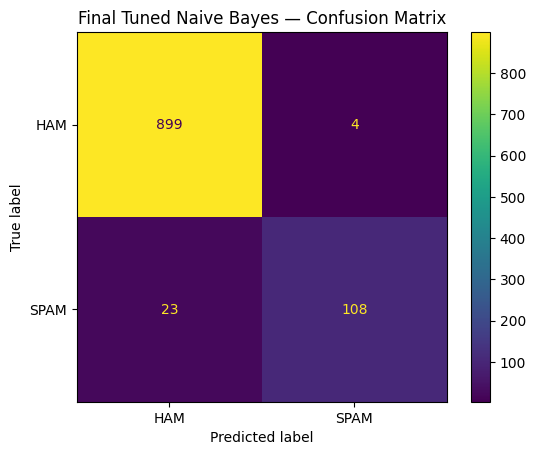

In [96]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["HAM", "SPAM"]
)

disp.plot()

plt.title("Final Tuned Naive Bayes — Confusion Matrix")
plt.show()

## Final Tuned Model — Confusion Matrix Interpretation

The final Naive Bayes model uses a spam probability threshold of 0.20,
which was selected using the validation set.

The final test confusion matrix is:

- True Negatives (TN): 899
- False Positives (FP): 4
- False Negatives (FN): 23
- True Positives (TP): 108

Compared with the default threshold of 0.50, the tuned threshold:
- detected 13 additional spam messages
- reduced missed spam messages from 36 to 23
- introduced 4 false-positive classifications

This demonstrates the trade-off between spam recall and false-positive
errors when changing the classification threshold.

In [97]:
# Final tuned model — false negative analysis

false_negative_mask_final = (
    (y_test == 1) &
    (y_test_threshold == 0)
)

false_negatives_final = pd.DataFrame({
    "message": X_test[false_negative_mask_final],
    "actual": y_test[false_negative_mask_final],
    "predicted": y_test_threshold[false_negative_mask_final],
    "spam_probability": test_spam_probabilities[false_negative_mask_final]
})

false_negatives_final = false_negatives_final.sort_values(
    "spam_probability",
    ascending=False
)

false_negatives_final

,message,actual,predicted,spam_probability
4752,TheMob>Hit the link to get a premium Pink Pant...,1,0,0.195257
5137,Want explicit SEX in 30 secs? Ring 02073162414...,1,0,0.188669
1644,"Free msg. Sorry, a service you ordered from 81...",1,0,0.164388
1094,"Bored of speed dating? Try SPEEDCHAT, txt SPEE...",1,0,0.159530
4476,Santa calling! Would your little ones like a c...,1,0,0.154138
2179,88066 FROM 88066 LOST 3POUND HELP,1,0,0.144405
1892,Guess what! Somebody you know secretly fancies...,1,0,0.132239
3741,ringtoneking 84484,1,0,0.126360
5062,"Latest News! Police station toilet stolen, cop...",1,0,0.109481
660,SMS. ac sun0819 posts HELLO:\You seem cool,1,0,0.105058


## Final Error Analysis

The final tuned model produced 23 false negatives on the test set.

Inspection of these errors revealed several recurring patterns:

1. Short spam messages contain very few textual features.
2. Some spam messages resemble normal conversational messages.
3. Promotional and service-related messages can use language similar to legitimate communications.
4. Some messages contain unusual wording or domain-specific expressions that are difficult for a simple TF-IDF representation to capture.
5. Several false negatives have probabilities close to the decision threshold, while others receive very low spam probabilities.

This indicates that threshold tuning can improve the precision-recall trade-off,
but it cannot completely solve errors caused by limitations in the feature
representation.

Further improvements could include character-level TF-IDF, richer n-gram
features, class-weighted models, ensemble methods, or transformer-based
text representations.

In [98]:
# Final tuned model — false positive analysis

false_positive_mask_final = (
    (y_test == 0) &
    (y_test_threshold == 1)
)

false_positives_final = pd.DataFrame({
    "message": X_test[false_positive_mask_final],
    "actual": y_test[false_positive_mask_final],
    "predicted": y_test_threshold[false_positive_mask_final],
    "spam_probability": test_spam_probabilities[false_positive_mask_final]
})

false_positives_final = false_positives_final.sort_values(
    "spam_probability",
    ascending=False
)

false_positives_final

,message,actual,predicted,spam_probability
4536,Nokia phone is lovly..,0,1,0.449062
4319,"Received, understood n acted upon!",0,1,0.297906
1252,Hey...Great deal...Farm tour 9am to 5pm $95/pa...,0,1,0.286647
564,Waiting for your call.,0,1,0.218704


## False Positive Analysis

The tuned model produced 4 false positives.

These messages show that some legitimate HAM messages contain vocabulary or
writing patterns that resemble spam.

Examples include:

- Product or brand-related wording
- Promotional expressions such as "Great deal"
- Very short SMS-style messages
- Phone/call-related expressions

The highest-confidence false positive was:

"Nokia phone is lovly.."

with a spam probability of approximately 0.449.

These errors demonstrate that increasing spam recall can introduce some
false-positive classifications. This is an important consideration for a
real spam filtering system because incorrectly moving a legitimate message
to the spam folder can negatively affect the user experience.

The error analysis suggests that future versions should improve contextual
understanding rather than relying only on word-frequency features.

## New Message Prediction

The trained model can now be used to classify previously unseen messages.

For a new message, the system:

1. Applies the same text preprocessing used during training.
2. Converts the message into TF-IDF features.
3. Calculates the probability of the message being spam.
4. Applies the selected classification threshold of 0.20.
5. Returns the predicted class and spam probability.

This simulates how the trained classifier could be used on incoming messages.

In [99]:
def predict_spam(message):
    # Clean the message using the same preprocessing
    cleaned_message = clean_text(message)

    # Convert text into TF-IDF features
    message_tfidf = tfidf_final.transform([cleaned_message])

    # Calculate spam probability
    spam_probability = nb_final.predict_proba(message_tfidf)[0, 1]

    # Apply final threshold
    prediction = int(spam_probability >= FINAL_THRESHOLD)

    # Convert prediction to label
    label = "SPAM" if prediction == 1 else "HAM"

    return label, spam_probability

In [100]:
message = "Congratulations! You won a $1000 prize. Click here to claim now!"

label, probability = predict_spam(message)

print("Message:", message)
print("Prediction:", label)
print(f"Spam Probability: {probability:.2%}")

Message: Congratulations! You won a $1000 prize. Click here to claim now!
Prediction: SPAM
Spam Probability: 96.20%


### Prediction Result

The classifier correctly identified the sample message as SPAM with a
spam probability of 96.20%.

This demonstrates that the trained model can process a previously unseen
message using the same preprocessing, TF-IDF representation, and tuned
classification threshold used during evaluation.

In [101]:
test_messages = [
    "Hey, are we still meeting at 6pm today?",
    "Congratulations! You have won a £1000 cash prize. Call now!",
    "Can you send me the notes from today's class?",
    "URGENT! You have been selected for a free reward. Click the link now!",
    "I'll call you when I reach home.",
    "Free entry! Text WIN to 80082 to claim your prize."
]

for message in test_messages:
    label, probability = predict_spam(message)

    print("-" * 70)
    print("Message:", message)
    print("Prediction:", label)
    print(f"Spam Probability: {probability:.2%}")

----------------------------------------------------------------------
Message: Hey, are we still meeting at 6pm today?
Prediction: HAM
Spam Probability: 0.58%
----------------------------------------------------------------------
Message: Congratulations! You have won a £1000 cash prize. Call now!
Prediction: SPAM
Spam Probability: 97.58%
----------------------------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: HAM
Spam Probability: 1.47%
----------------------------------------------------------------------
Message: URGENT! You have been selected for a free reward. Click the link now!
Prediction: SPAM
Spam Probability: 83.44%
----------------------------------------------------------------------
Message: I'll call you when I reach home.
Prediction: HAM
Spam Probability: 0.93%
----------------------------------------------------------------------
Message: Free entry! Text WIN to 80082 to claim your prize.
Prediction: SPAM

## Multiple Message Testing

Testing multiple unseen messages provides a simple qualitative validation
of the classifier's behavior.

The examples include both conversational HAM messages and promotional or
urgent SPAM messages.

The model's prediction is based on the learned TF-IDF representation and
the probability threshold selected using the validation set.

## Multiple Message Testing — Interpretation

The classifier correctly classified all six manually created test messages.

Conversational messages received low spam probabilities, while messages
containing prize, reward, urgency, and promotional language received high
spam probabilities.

These examples demonstrate how the classifier behaves on new input.

However, these manually created examples are only a qualitative sanity
check. They are not used to calculate the model's official test-set
performance.

# Model Training, Validation, Evaluation & Deployment

## 1. Dataset Preparation

| Step | Description |
|---|---|
| 1 | Original Dataset |
| 2 | Cleaned Dataset |
| 3 | Train / Test Split |

---

## 2. Training & Validation

| Step | Description |
|---|---|
| 1 | Training Data — 4,135 messages |
| 2 | Train / Validation Split |
| 3 | Model Training |
| 4 | Validation |
| 5 | Threshold Selection |
| 6 | Final Threshold — **0.20** |

---

## 3. Final Test Evaluation

**Test Data:** 1,034 messages

| Metric | Result |
|---|---:|
| Accuracy | **97.39%** |
| Precision | **96.43%** |
| Recall | **82.44%** |
| F1-Score | **88.89%** |

---

## 4. Deployment

| Step | Description |
|---|---|
| 1 | Use all 4,135 training messages |
| 2 | Retrain Deployment Model |
| 3 | Freeze Threshold — **0.20** |
| 4 | Save Model + TF-IDF Vectorizer |
| 5 | Reusable Spam Classifier |

In [102]:
# Prepare all original training data
X_train_deploy_clean = X_train.apply(clean_text)

# Fit TF-IDF on all non-test training data
tfidf_deploy = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_deploy_tfidf = tfidf_deploy.fit_transform(
    X_train_deploy_clean
)

print("Deployment TF-IDF shape:", X_train_deploy_tfidf.shape)

Deployment TF-IDF shape: (4135, 5000)


##  Train Deployment Model

The validation and final test evaluation have been completed.

The classification threshold was selected using the validation set and
fixed at **0.20**.

We can now retrain the Naive Bayes model using all **4,135 non-test
training messages**.

The test set remains untouched and is not used during deployment training.

In [103]:
# Train the deployment Naive Bayes model
nb_deploy = MultinomialNB()

nb_deploy.fit(
    X_train_deploy_tfidf,
    y_train
)

print("Deployment model trained successfully.")
print("Training samples:", X_train_deploy_tfidf.shape[0])
print("Features:", X_train_deploy_tfidf.shape[1])
print("Final threshold:", FINAL_THRESHOLD)

Deployment model trained successfully.
Training samples: 4135
Features: 5000
Final threshold: 0.2


##  Save Deployment Model

The trained deployment model, TF-IDF vectorizer, and classification
threshold are saved together as a single model artifact.

This allows the complete spam classification system to be loaded later
and used for predictions without repeating the training process.

In [104]:
import joblib

deployment_artifact = {
    "model": nb_deploy,
    "vectorizer": tfidf_deploy,
    "threshold": FINAL_THRESHOLD
}

model_file = "spam_classifier_deployment.joblib"

joblib.dump(
    deployment_artifact,
    model_file
)

print("Deployment model saved successfully.")
print("File:", model_file)

Deployment model saved successfully.
File: spam_classifier_deployment.joblib


## Load Saved Deployment Model

The saved deployment artifact is loaded back into memory.

The artifact contains:

- The trained Naive Bayes model
- The fitted TF-IDF vectorizer
- The fixed classification threshold

This verifies that the trained classifier can be restored without retraining.

In [105]:
import joblib

loaded_artifact = joblib.load(
    "spam_classifier_deployment.joblib"
)

loaded_model = loaded_artifact["model"]
loaded_vectorizer = loaded_artifact["vectorizer"]
loaded_threshold = loaded_artifact["threshold"]

print("Deployment model loaded successfully.")
print("Model:", type(loaded_model).__name__)
print("Vectorizer:", type(loaded_vectorizer).__name__)
print("Threshold:", loaded_threshold)

Deployment model loaded successfully.
Model: MultinomialNB
Vectorizer: TfidfVectorizer
Threshold: 0.2


## Verify Saved Deployment Model

The saved deployment model has been successfully loaded.

We now verify that the restored model can classify a completely new
message using the saved TF-IDF vectorizer and the frozen threshold of 0.20.

This confirms that the saved model artifact is usable for inference.

In [106]:
def predict_with_loaded_model(message):
    # Apply the same preprocessing
    cleaned_message = clean_text(message)

    # Transform using the saved TF-IDF vectorizer
    message_tfidf = loaded_vectorizer.transform([cleaned_message])

    # Calculate spam probability
    spam_probability = loaded_model.predict_proba(
        message_tfidf
    )[0, 1]

    # Apply saved threshold
    prediction = int(
        spam_probability >= loaded_threshold
    )

    label = "SPAM" if prediction == 1 else "HAM"

    return label, spam_probability

In [107]:
test_message = "Congratulations! You won a $1000 prize. Click here to claim now!"

label, probability = predict_with_loaded_model(test_message)

print("Message:", test_message)
print("Prediction:", label)
print(f"Spam Probability: {probability:.2%}")

Message: Congratulations! You won a $1000 prize. Click here to claim now!
Prediction: SPAM
Spam Probability: 97.49%


##  Multiple Message Testing — Saved Deployment Model

The saved deployment model is now tested against multiple previously unseen
messages containing both HAM and SPAM examples.

This verifies that the complete saved model artifact can perform inference
after being loaded, without requiring retraining.

In [108]:
test_messages = [
    "Hey, are we still meeting at 6pm today?",
    "Congratulations! You have won a £1000 cash prize. Call now!",
    "Can you send me the notes from today's class?",
    "URGENT! You have been selected for a free reward. Click the link now!",
    "I'll call you when I reach home.",
    "Free entry! Text WIN to 80082 to claim your prize."
]

for message in test_messages:
    label, probability = predict_with_loaded_model(message)

    print("-" * 70)
    print("Message:", message)
    print("Prediction:", label)
    print(f"Spam Probability: {probability:.2%}")

----------------------------------------------------------------------
Message: Hey, are we still meeting at 6pm today?
Prediction: HAM
Spam Probability: 0.56%
----------------------------------------------------------------------
Message: Congratulations! You have won a £1000 cash prize. Call now!
Prediction: SPAM
Spam Probability: 98.57%
----------------------------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: HAM
Spam Probability: 2.25%
----------------------------------------------------------------------
Message: URGENT! You have been selected for a free reward. Click the link now!
Prediction: SPAM
Spam Probability: 87.03%
----------------------------------------------------------------------
Message: I'll call you when I reach home.
Prediction: HAM
Spam Probability: 1.09%
----------------------------------------------------------------------
Message: Free entry! Text WIN to 80082 to claim your prize.
Prediction: SPAM

## 10. Final Project Results

### Model

**Multinomial Naive Bayes + TF-IDF**

- TF-IDF features: **5,000**
- N-gram range: **1–2**
- Classification threshold: **0.20**

### Final Test Performance

| Metric | Result |
|---|---:|
| Accuracy | **97.39%** |
| Precision | **96.43%** |
| Recall | **82.44%** |
| F1-Score | **88.89%** |

### Confusion Matrix

| | Predicted HAM | Predicted SPAM |
|---|---:|---:|
| **Actual HAM** | 899 | 4 |
| **Actual SPAM** | 23 | 108 |

### Key Findings

- The tuned threshold increased SPAM recall from **72.52% → 82.44%**.
- False negatives decreased from **36 → 23**.
- False positives increased from **0 → 4**.
- The model successfully classified manually created HAM and SPAM examples.
- The deployment artifact can be saved, loaded, and used for inference without retraining.

### Important Limitation

This is a **V1 machine-learning classifier** based on TF-IDF and Naive Bayes.
It is not yet a complete email-filtering system connected to Gmail or another
mail provider.

Future versions can improve contextual understanding, handle production
email ingestion, collect user feedback, monitor model performance, and
support automated spam-folder routing.